# Polynomial chaos MPC for uncertain heat pump control

End-to-end notebook that combines the MPC utilities in `src/controller/pc_mpc/core.py` with the non-intrusive PCE helpers in `pce_uncertain_mpc.py`. The flow is:

- build a nominal building + heat pump model and disturbances,
- define parameter uncertainty and a chaos basis,
- run one closed-loop MPC rollout and capture the open-loop plan from the first solve,
- regress a PCE for the open-loop prediction to get mean/variance vs. uncertainty.


In [23]:
# Imports and path setup so repo-local modules are importable in the notebook
import sys
from pathlib import Path

# Numeric and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

# Ensure the repo root is importable when running the notebook directly
REPO_ROOT = Path.cwd().resolve().parent
if (REPO_ROOT / 'src').exists() and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# MPC + PCE utilities
from src.controller.pc_mpc import (
    PcMpcRunner,
    PolynomialChaosBasis,
    UncertaintyModel,
    MultiplicativePlantBuilder,
    compute_pce_coeffs,
)
# Models and disturbances
import src.models.model_hvac as model_hvac
import src.models.model_buildings as model_buildings
import src.disturbances as disturbances
from data.buildings import i4c


## Nominal model and disturbances

Select the building (i4c KfW-40) and heat pump, choose sampling and horizons, and generate disturbances from local CSVs. `repo_filepath` keeps file lookups robust regardless of the current working directory.

In [24]:
# Core simulation settings
h = 3600  # sampling time [s]
nk = 24  # prediction horizon steps (1 day @ 1 h)
mpc_steps = 24  # number of closed-loop MPC iterations to run
mdot_hp = 0.25  # heat pump mass flow [kg/s]

# Nominal building and heat pump models
building_model = model_buildings.Building(
    params=i4c,
    mdot_hp=mdot_hp,
    method='2R2C',
    T_room_set_lower=20,
    T_room_set_upper=26,
)

hp_model = model_hvac.Heatpump_AW(mdot_HP=mdot_hp)

# Build disturbance dataframe and trim to the time window we simulate
raw_disturbances = disturbances.generate_disturbances_all(
    building_model=building_model,
    timestep=h,
    GRID_ON=False,
    repo_filepath=str(REPO_ROOT),
)

# MPC expects columns [T_amb, Qdot_gains, T_room_set_lower, grid]
disturbance_cols = ['T_amb', 'Qdot_gains', 'T_room_set_lower', 'grid']
disturbances_df = raw_disturbances.loc[:, disturbance_cols]
disturbances_df = disturbances_df.iloc[: nk + mpc_steps + 2]

# Initial state guess for the MPC (room/wall slightly different, return warmer)
x0_dict = {key: 20.0 for key in building_model.state_keys}
if 'T_wall' in x0_dict:
    x0_dict['T_wall'] = 19.0
if 'T_hp_ret' in x0_dict:
    x0_dict['T_hp_ret'] = 22.0

pd.DataFrame({'disturbance_rows': [len(disturbances_df)], 'state_keys': [building_model.state_keys]})


,disturbance_rows,state_keys
0,50,"(T_room, T_hp_ret)"


## Uncertainty model and basis

Model multiplicative uncertainty on `H_ve` and `H_tr` (ventilation and transmission losses). Use a 2D Hermite basis of total order 2 for Gaussian `xi`. Adjust `theta_bar`/`L` or `order`/`kind` to match your study.

In [25]:
# Parameter uncertainty: multiplicative factors around nominal H_ve and H_tr
theta_bar = np.ones(2)
L = np.diag([0.1, 0.05])  # 10 % std on H_ve, 5 % on H_tr
uncertainty = UncertaintyModel(theta_bar=theta_bar, L=L)

# Build uncertain plant by scaling the two parameters
plant_builder = MultiplicativePlantBuilder(
    base_building=building_model,
    param_keys=('H_ve', 'H_tr'),
)

# Chaos basis for Gaussian xi (Hermite)
basis = PolynomialChaosBasis(dim=uncertainty.dim, order=2, kind='hermite')

basis.size


6

## Closed-loop MPC sample

Run a short receding-horizon rollout for one `xi` draw to get a representative trajectory and capture the initial open-loop control plan for PCE regression.

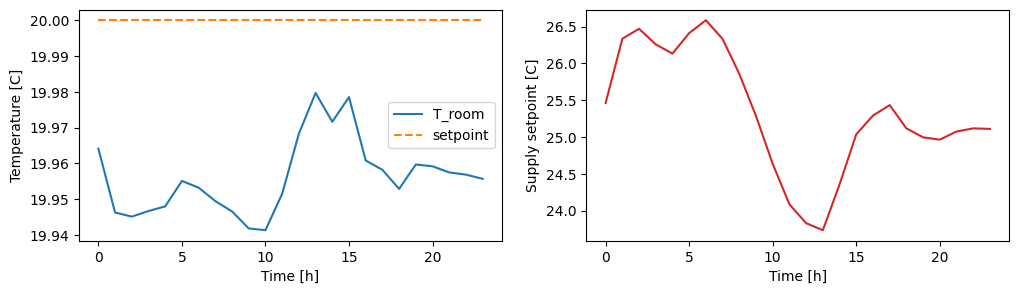

{'violation_probability': 1.0,
 'max_violation': 0.05864585802751421,
 'avg_violation': 0.04380806087731267,
 'avg_pel_kw': 0.6925876730337807,
 'total_energy_kwh': 16.622104152810735,
 'grid_cost': 16.622104152810735}

In [33]:
# Closed-loop rollout for one xi draw and capture the initial open-loop plan
controller = PcMpcRunner(
    hp_model=hp_model,
    building_model_nominal=building_model,
    disturbances=disturbances_df,
    theta_from_xi=uncertainty.theta_from_xi,
    plant_builder=plant_builder,
    nk=nk,
    h=h,
    step_length=1,
    ws=0.2,
    npar=len(disturbance_cols),
)

# Uncertainty influences the plant model built inside the runner; xi controls scaling of H_ve/H_tr
sample = controller.run_sample(
    x0=x0_dict,
    xi_sample=np.array([1.0, -0.5])*10, #np.zeros(uncertainty.dim),
    #xi_sample=np.zeros(uncertainty.dim),
    mpc_steps=mpc_steps,
    capture_plan=True,
)
traj = sample['trajectory']

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=True)
time_hours = traj['time'] / 3600.0

axes[0].plot(time_hours, traj['T_room'], label='T_room')
axes[0].plot(time_hours, traj['T_room_set_lower'], '--', label='setpoint')
axes[0].set_ylabel('Temperature [C]')
axes[0].legend()

axes[1].plot(time_hours, traj['T_hp_sup'], color='tab:red')
axes[1].set_ylabel('Supply setpoint [C]')

for ax in axes:
    ax.set_xlabel('Time [h]')
plt.show()

sample['stats']


## Polynomial chaos regression of the prediction

With the open-loop plan and disturbance sequence frozen, regress the non-intrusive PCE of the plant response over the uncertainty space. Extract mean and variance of room temperature over the prediction horizon.

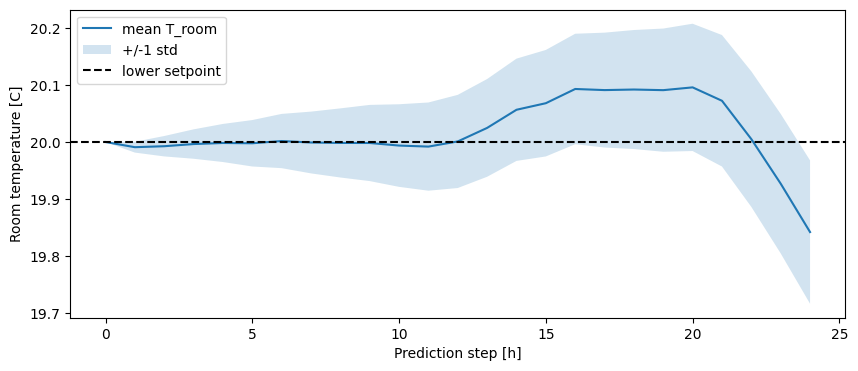

In [28]:
# Regress non-intrusive PCE of the open-loop prediction
if 'plan' not in sample:
    raise RuntimeError('Open-loop plan was not returned; set capture_plan=True and ensure MPC_solver supports return_res.')

u_plan = np.asarray(sample['plan']['u_sequence']).reshape(nk, -1)
p_seq = disturbances_df.iloc[: nk + 1, : controller.npar].values

pce_result = compute_pce_coeffs(
    x0=np.array([x0_dict[k] for k in building_model.state_keys]),
    u_seq=u_plan,
    p_seq=p_seq,
    basis=basis,
    theta_from_xi=uncertainty.theta_from_xi,
    building_model_nominal=building_model,
    plant_builder=plant_builder,
    h=h,
)

room_idx = building_model.state_keys.index('T_room')
mean_room = [pce_result.mean(k)[room_idx] for k in range(pce_result.beta.shape[0])]
std_room = [np.sqrt(pce_result.var(k)[room_idx]) for k in range(pce_result.beta.shape[0])]
hours_pred = np.arange(len(mean_room)) * (h / 3600.0)

plt.figure(figsize=(10, 4))
plt.plot(hours_pred, mean_room, label='mean T_room')
plt.fill_between(hours_pred, np.array(mean_room) - np.array(std_room), np.array(mean_room) + np.array(std_room), alpha=0.2, label='+/-1 std')
plt.axhline(disturbances_df['T_room_set_lower'].iloc[0], color='k', linestyle='--', label='lower setpoint')
plt.xlabel('Prediction step [h]')
plt.ylabel('Room temperature [C]')
plt.legend()
plt.show()
